# Multiple Crop Disease Prediction

## Libraries

In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import matplotlib.pyplot as plt

In [2]:
# Configuration
data_dir = "/kaggle/input/plantvillage/PlantVillage"

batch_size = 32
num_epochs = 10
learning_rate = 1e-4
patience = 5
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


## Dataset

In [ ]:
# Data transforms and loaders
train_transform = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)
val_test_transform = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

train_loader = DataLoader(
    datasets.ImageFolder(os.path.join(data_dir, "train"), transform=train_transform),
    batch_size=batch_size,
    shuffle=True,
    num_workers=4,
)
val_loader = DataLoader(
    datasets.ImageFolder(os.path.join(data_dir, "val"), transform=val_test_transform),
    batch_size=batch_size,
    shuffle=False,
    num_workers=4,
)

num_classes = len(train_loader.dataset.classes)
print(len(train_loader.dataset))

43444


## Model definition

In [ ]:
# Model definition (StackedCNN as before)
class StackedCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        def conv_block(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
            )

        self.features = nn.Sequential(
            conv_block(3, 32),
            conv_block(32, 64),
            conv_block(64, 128),
            conv_block(128, 256),
            conv_block(256, 512),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 7 * 7, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(1024, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


model = StackedCNN(num_classes).to(device)

In [5]:
print(model)

StackedCNN(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (2): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (3): Sequential(
      (

## Training

In [ ]:
# Loss, optimizer, scheduler
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=2
)

In [ ]:
# Training loop with metric tracking
train_losses, val_losses = [], []
train_accs, val_accs = [], []

best_val_acc = 0.0
epochs_no_improve = 0

for epoch in range(1, num_epochs + 1):
    # Training
    model.train()
    running_loss = 0.0
    all_preds, all_labels = [], []
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    epoch_train_loss = running_loss / len(train_loader.dataset)
    epoch_train_acc = accuracy_score(all_labels, all_preds)

    # Validation
    model.eval()
    running_val_loss = 0.0
    val_preds, val_labels = [], []
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())
    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    epoch_val_acc = accuracy_score(val_labels, val_preds)

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    train_accs.append(epoch_train_acc)
    val_accs.append(epoch_val_acc)

    scheduler.step(epoch_val_acc)

    print(
        f"Epoch {epoch}: Train Loss={epoch_train_loss:.4f}, Train Acc={epoch_train_acc:.4f}, "
        f"Val Loss={epoch_val_loss:.4f}, Val Acc={epoch_val_acc:.4f}"
    )

    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        epochs_no_improve = 0
        torch.save(model.state_dict(), "best_model.pth")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print("Early stopping triggered.")
            break

Epoch 1: Train Loss=1.0969, Train Acc=0.6857, Val Loss=0.3719, Val Acc=0.8829
Epoch 2: Train Loss=0.4679, Train Acc=0.8542, Val Loss=0.2327, Val Acc=0.9244
Epoch 3: Train Loss=0.3252, Train Acc=0.8972, Val Loss=0.1758, Val Acc=0.9425
Epoch 4: Train Loss=0.2567, Train Acc=0.9179, Val Loss=0.1279, Val Acc=0.9581
Epoch 5: Train Loss=0.2120, Train Acc=0.9312, Val Loss=0.0768, Val Acc=0.9759
Epoch 6: Train Loss=0.1842, Train Acc=0.9388, Val Loss=0.0946, Val Acc=0.9684
Epoch 7: Train Loss=0.1610, Train Acc=0.9473, Val Loss=0.0873, Val Acc=0.9710
Epoch 8: Train Loss=0.1470, Train Acc=0.9510, Val Loss=0.0661, Val Acc=0.9778
Epoch 9: Train Loss=0.1306, Train Acc=0.9570, Val Loss=0.0678, Val Acc=0.9770
Epoch 10: Train Loss=0.1190, Train Acc=0.9602, Val Loss=0.0523, Val Acc=0.9828


## Results

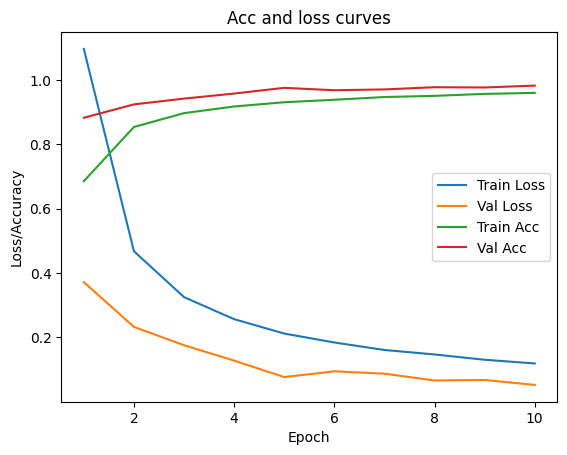

In [ ]:
# Plotting training curves
plt.figure()
plt.plot(range(1, len(train_losses) + 1), train_losses, label="Train Loss")
plt.plot(range(1, len(val_losses) + 1), val_losses, label="Val Loss")
plt.plot(range(1, len(train_accs) + 1), train_accs, label="Train Acc")
plt.plot(range(1, len(val_accs) + 1), val_accs, label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Loss/Accuracy")
plt.title("Acc and loss curves")
plt.legend()
# plt.savefig("acc_curves.pdf", bbox_inches="tight")
plt.show()

In [ ]:
model.load_state_dict(
    torch.load("/kaggle/input/crop_disease_model/pytorch/default/1/best_model.pth")
)
model.to(device)

/tmp/ipykernel_31/4155054081.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("/kaggle/input/crop_disease_model/pytorch/default/1/best_mo

In [ ]:
# Evaluation on test set
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

acc = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds, average="weighted")
rec = recall_score(all_labels, all_preds, average="weighted")
f1 = f1_score(all_labels, all_preds, average="weighted")

print(f"Test Accuracy: {acc:.4f}")
print(f"Test Precision: {prec:.4f}")
print(f"Test Recall: {rec:.4f}")
print(f"Test F1 Score: {f1:.4f}")

Test Accuracy: 0.9828
Test Precision: 0.9830
Test Recall: 0.9828
Test F1 Score: 0.9827


In [ ]:
from PIL import Image

# Image transformation for inference
input_transform = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)


def predict_image(image_path, model, class_names):
    model.eval()
    image = Image.open(image_path).convert("RGB")
    image_tensor = input_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(image_tensor)
        predicted_index = outputs.argmax(dim=1).item()

    return class_names[predicted_index]

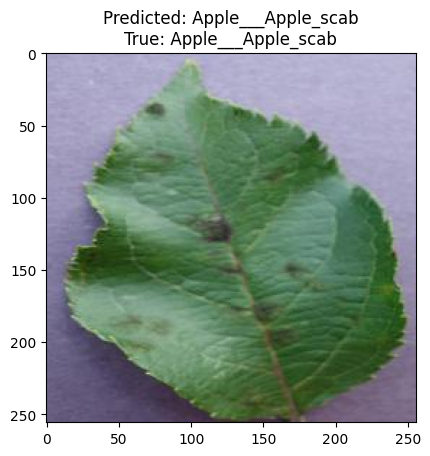

In [ ]:
# Automatically extract class names if not done already
class_names = train_loader.dataset.classes

image_path = "/kaggle/input/plantvillage/PlantVillage/val/Apple___Apple_scab/00075aa8-d81a-4184-8541-b692b78d398a___FREC_Scab 3335.JPG"
true_label = ""

for label in class_names:
    if label in image_path:
        true_label = label

# Predict a test image
predicted_label = predict_image(image_path, model, class_names)

# plot the prediction
image = Image.open(image_path).convert("RGB")
plt.imshow(image)
plt.title(f"Predicted: {predicted_label}\nTrue: {true_label}")
plt.show()